# Supermarket Sales Analysis

Analysis of supermarket sales data to identify sales patterns, branch performance, customer behavior, and key business insights.

## 1. Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('SuperMarket Analysis.csv')

In [3]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## 2. Data Quality Check

Checking dataset dimensions, data types, missing values, duplicates, and transaction ID uniqueness.

In [4]:
df.shape


(1000, 17)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [6]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Invoice ID'].nunique()

1000

## 3. Feature Engineering

Converting date and time columns into appropriate formats and creating time-based features for further analysis.

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df['Hour'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.hour

In [11]:
def get_time_of_day(hour):
    if hour < 12:
        return 'Morning'
    elif hour < 17:
        return 'Afternoon'
    else:
        return 'Evening'

In [12]:
df['time_of_day'] = df['Hour'].apply(get_time_of_day)

In [13]:
df[['Time', 'Hour', 'time_of_day']].head()

,Time,Hour,time_of_day
0,1:08:00 PM,13,Afternoon
1,10:29:00 AM,10,Morning
2,1:23:00 PM,13,Afternoon
3,8:33:00 PM,20,Evening
4,10:37:00 AM,10,Morning


## 4. KPI Analysis

Calculating overall sales KPIs and comparing performance across branches.

In [14]:
total_sales = df['Sales'].sum()
total_transactions = df['Invoice ID'].nunique()
average_transaction = df['Sales'].mean()
total_gross_income = df['gross income'].sum()

total_sales, total_transactions, average_transaction, total_gross_income

(np.float64(322966.749),
 1000,
 np.float64(322.966749),
 np.float64(15379.368999999999))

In [15]:
branch_summary = (
    df.groupby('Branch')
    .agg(
        total_sales=('Sales', 'sum'),
        transactions=('Invoice ID', 'nunique'),
        average_transaction=('Sales', 'mean'),
        gross_income=('gross income', 'sum'),
        average_rating=('Rating', 'mean')
    )
    .reset_index()
    .round(2)
)

branch_summary

,Branch,total_sales,transactions,average_transaction,gross_income,average_rating
0,Alex,106200.37,340,312.35,5057.16,7.03
1,Cairo,106197.67,332,319.87,5057.03,6.82
2,Giza,110568.71,328,337.10,5265.18,7.07


## 5. Product Line Analysis

Analyzing sales performance across product categories and branches.

In [16]:
df.groupby('Product line')['Sales'].sum()

Product line
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Food and beverages        56144.8440
Health and beauty         49193.7390
Home and lifestyle        53861.9130
Sports and travel         55122.8265
Name: Sales, dtype: float64

In [17]:
product_sales_by_branch = (
    df.groupby(['Branch', 'Product line'])['Sales']
    .sum()
    .reset_index()
)

product_sales_by_branch

,Branch,Product line,Sales
0,Alex,Electronic accessories,18317.1135
1,Alex,Fashion accessories,16332.5085
2,Alex,Food and beverages,17163.1005
3,Alex,Health and beauty,12597.7530
4,Alex,Home and lifestyle,22417.1955
5,Alex,Sports and travel,19372.6995
6,Cairo,Electronic accessories,17051.4435
7,Cairo,Fashion accessories,16413.3165
8,Cairo,Food and beverages,15214.8885
9,Cairo,Health and beauty,19980.6600


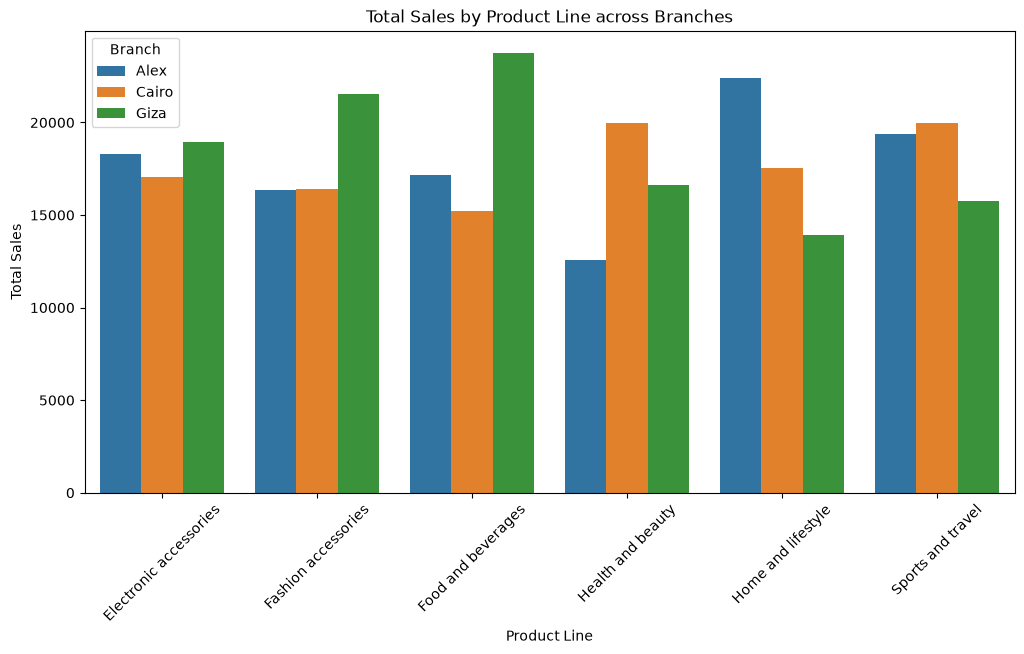

In [18]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=product_sales_by_branch,
    x='Product line',
    y='Sales',
    hue='Branch'
)

plt.title('Total Sales by Product Line across Branches')
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.show()

### Key Insight

Food and Beverages generated the highest overall sales, while Health and Beauty had the lowest.

Product performance differs across branches:
- Alex performs strongest in Home and Lifestyle.
- Cairo performs strongest in Sports and Travel.
- Giza performs strongest in Food and Beverages.

## 6. Payment Analysis

Analyzing how payment methods contribute to sales across different branches.

In [19]:
payment_sales_by_branch = (
    df.groupby(['Branch', 'Payment'])['Sales']
    .sum()
    .reset_index()
)

payment_sales_by_branch

,Branch,Payment,Sales
0,Alex,Cash,33781.2510
1,Alex,Credit card,33094.7505
2,Alex,Ewallet,39324.3690
3,Cairo,Cash,35339.4615
4,Cairo,Credit card,37344.8565
5,Cairo,Ewallet,33513.3540
6,Giza,Cash,43085.8575
7,Giza,Credit card,30327.4650
8,Giza,Ewallet,37155.3840


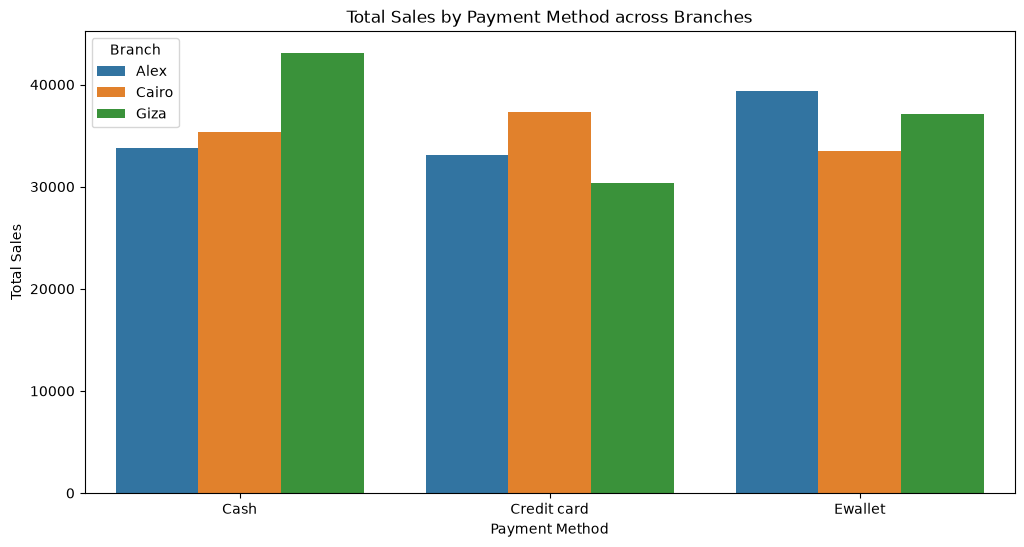

In [20]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=payment_sales_by_branch,
    x='Payment',
    y='Sales',
    hue='Branch'
)

plt.title('Total Sales by Payment Method across Branches')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales')

plt.show()

### Key Insight

The payment method generating the highest sales varies by branch:

- Alex generates the highest sales through Ewallet.
- Cairo generates the highest sales through Credit Card.
- Giza generates the highest sales through Cash.

## 7. Time of Day Analysis

Analyzing how sales vary throughout the day across different branches.

In [21]:
time_sales_by_branch = (
    df.groupby(['Branch', 'time_of_day'])['Sales']
    .sum()
    .reset_index()
)

time_sales_by_branch

,Branch,time_of_day,Sales
0,Alex,Afternoon,50924.6745
1,Alex,Evening,32717.3910
2,Alex,Morning,22558.3050
3,Cairo,Afternoon,45807.1110
4,Cairo,Evening,41042.9040
5,Cairo,Morning,19347.6570
6,Giza,Afternoon,51291.5550
7,Giza,Evening,39384.3030
8,Giza,Morning,19892.8485


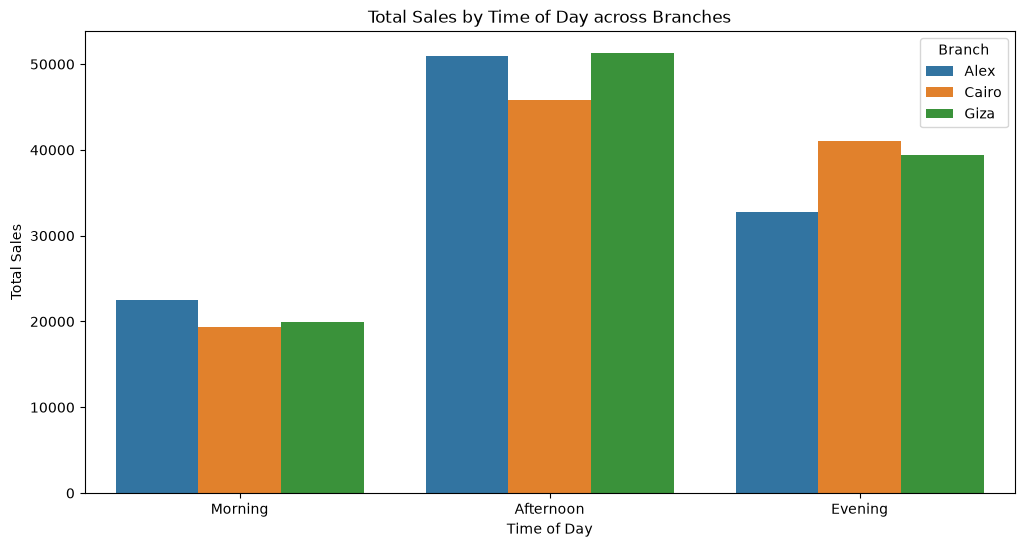

In [22]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=time_sales_by_branch,
    x='time_of_day',
    y='Sales',
    hue='Branch',
    order=['Morning', 'Afternoon', 'Evening']
)

plt.title('Total Sales by Time of Day across Branches')
plt.xlabel('Time of Day')
plt.ylabel('Total Sales')

plt.show()

### Key Insight

Afternoon is the strongest sales period across all three branches.

Morning generates the lowest sales, while evening sales remain below afternoon levels in every branch.

## 8. Customer Type Analysis

Comparing sales generated by Member and Normal customers across branches.

In [23]:
customer_sales_by_branch = (
    df.groupby(['Branch', 'Customer type'])['Sales']
    .sum()
    .reset_index()
)

customer_sales_by_branch

,Branch,Customer type,Sales
0,Alex,Member,62895.7770
1,Alex,Normal,43304.5935
2,Cairo,Member,59824.1700
3,Cairo,Normal,46373.5020
4,Giza,Member,66974.8170
5,Giza,Normal,43593.8895


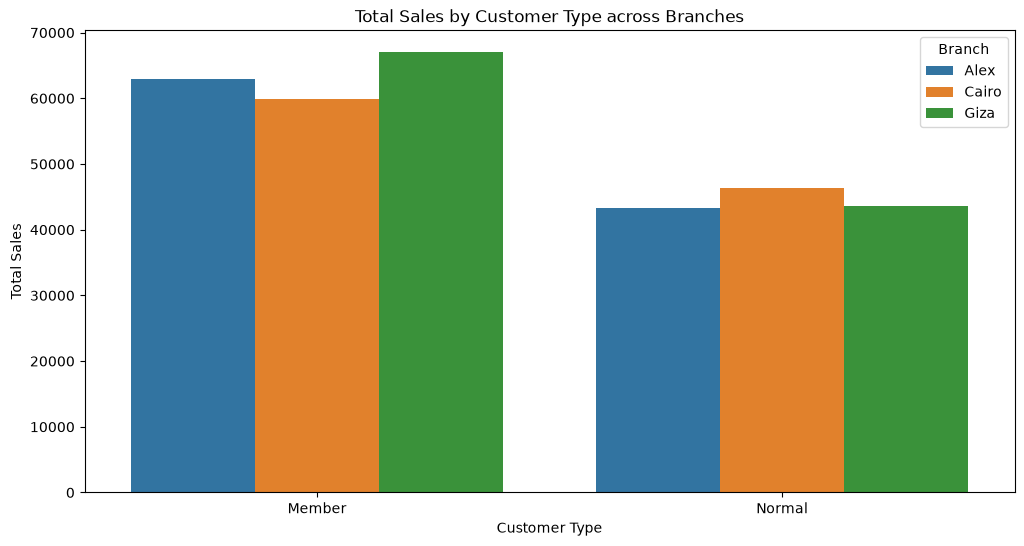

In [24]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=customer_sales_by_branch,
    x='Customer type',
    y='Sales',
    hue='Branch',
)

plt.title('Total Sales by Customer Type across Branches')
plt.xlabel('Customer Type')
plt.ylabel('Total Sales')

plt.show()

### Key Insight

Members generate higher total sales than Normal customers across all three branches.

Giza shows the highest sales from Member customers among all branches.

## 9. Conclusions

The analysis revealed several key insights about supermarket performance:

- Giza is the strongest-performing branch overall, generating the highest total sales, gross income, average transaction value, and average customer rating despite having the lowest number of transactions.
- Food and Beverages is the highest-selling product category overall, while Health and Beauty generates the lowest total sales.
- Product preferences vary across branches: Alex performs strongest in Home and Lifestyle, Cairo in Sports and Travel, and Giza in Food and Beverages.
- The highest-sales payment method differs by branch: Ewallet leads in Alex, Credit Card in Cairo, and Cash in Giza.
- Afternoon is the strongest sales period across all three branches, while morning consistently generates the lowest sales.
- Member customers generate higher total sales than Normal customers in every branch.

Overall, the results suggest that branch performance is influenced not only by transaction volume, but also by transaction value, customer type, product preferences, and purchasing time.